In [9]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

print("Random Forest Ready")

Random Forest Ready


In [3]:
import pandas as pd

# Load Dataset
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# Data Cleaning
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

df = df.drop(columns=['Cabin'], errors='ignore')

# Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# Remove unwanted columns
df = df.drop(columns=['Name','Ticket'], errors='ignore')

# Features and Target
X = df.drop('Survived', axis=1)
y = df['Survived']

# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Random Forest Model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

print("Model Ready")

Model Ready


In [4]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

       Feature  Importance
2          Sex    0.253610
6         Fare    0.193012
0  PassengerId    0.190469
3          Age    0.169629
1       Pclass    0.082862
4        SibSp    0.044399
5        Parch    0.033023
7     Embarked    0.032996


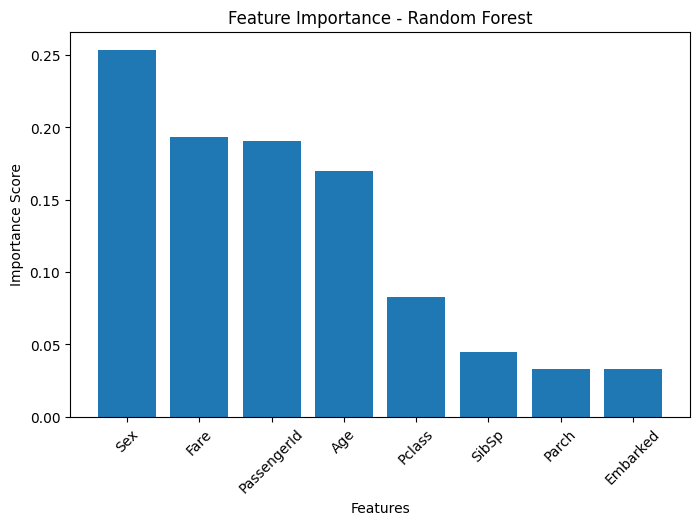

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xticks(rotation=45)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.show()